## Mini Project: Data Visualization with Pandas, Seaborn, and Matplotlib

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!unzip /content/drive/MyDrive/BootGenAI/Palmer_Penguins_Dataset.zip

Archive:  /content/drive/MyDrive/BootGenAI/Palmer_Penguins_Dataset.zip
  inflating: Palmer Penguins Dataset.csv  


### Data Loading and Cleaning:

In [18]:
import pandas as pd

df = pd.read_csv('/content/Palmer_Penguins_Dataset.csv')
df.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [20]:
# Check info and missing values
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 21.6+ KB
None
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64


In [29]:
#drop rows
df = df.dropna(axis=0)

### Exploratory Data Analysis (EDA):

In [31]:
print(df.describe())

       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
count      333.000000     333.000000         333.000000   333.000000   
mean        43.992793      17.164865         200.966967  4207.057057   
std          5.468668       1.969235          14.015765   805.215802   
min         32.100000      13.100000         172.000000  2700.000000   
25%         39.500000      15.600000         190.000000  3550.000000   
50%         44.500000      17.300000         197.000000  4050.000000   
75%         48.600000      18.700000         213.000000  4775.000000   
max         59.600000      21.500000         231.000000  6300.000000   

              year  
count   333.000000  
mean   2008.042042  
std       0.812944  
min    2007.000000  
25%    2007.000000  
50%    2008.000000  
75%    2009.000000  
max    2009.000000  


In [33]:
for col in ['species', 'island', 'sex']:
   print(f"{col} unique values:", df[col].unique())

species unique values: ['Adelie' 'Gentoo' 'Chinstrap']
island unique values: ['Torgersen' 'Biscoe' 'Dream']
sex unique values: ['male' 'female']


### Visualization Tasks:

/tmp/ipython-input-1969356160.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="species", data=df, palette="viridis") #compter le nombre d’occurrences de chaque catégorie.


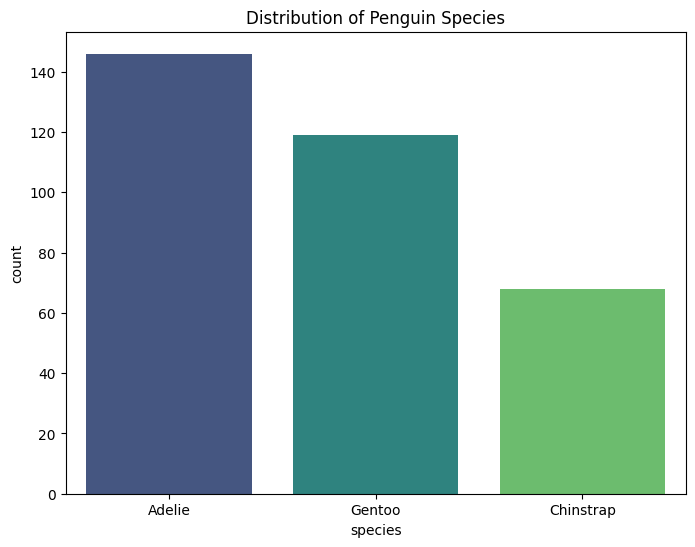

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x="species", data=df, palette="viridis") #compter le nombre d’occurrences de chaque catégorie.
# sns.barplot(x=df.groupby(species).index , y = df.groupby(species).values)
plt.title("Distribution of Penguin Species")
plt.show()

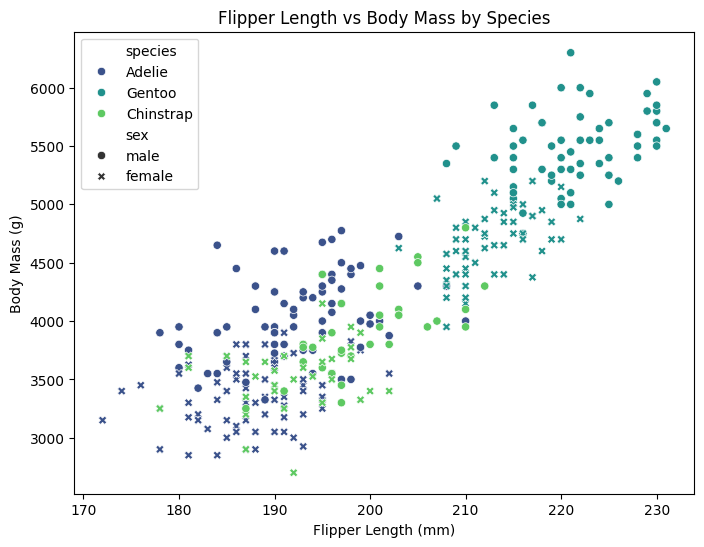

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Scatter plot: Flipper length vs Body mass
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species",   # couleur par espèce
    style="sex",     # optionnel : forme des points par sexe
    palette="viridis"
)

plt.title("Flipper Length vs Body Mass by Species")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")
plt.show()

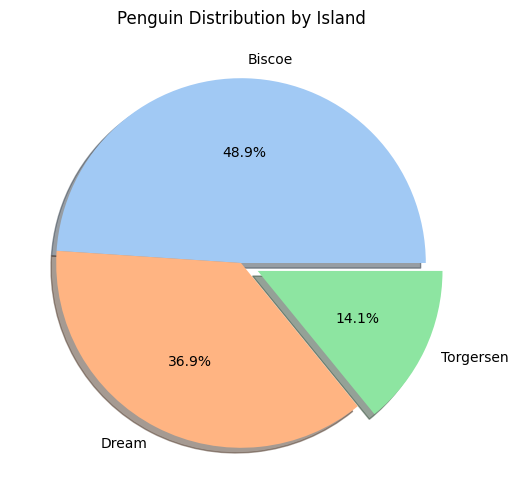

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compter le nombre de manchots par île
island_counts = df["island"].value_counts()

explode = (0, 0, 0.1) # explode the 1st slice (Apples)

# Créer le pie chart
plt.figure(figsize=(6,6))
plt.pie( island_counts, explode= explode, labels=island_counts.index, autopct="%1.1f%%", colors=sns.color_palette("pastel"), shadow=True)
plt.title("Penguin Distribution by Island")
plt.show()


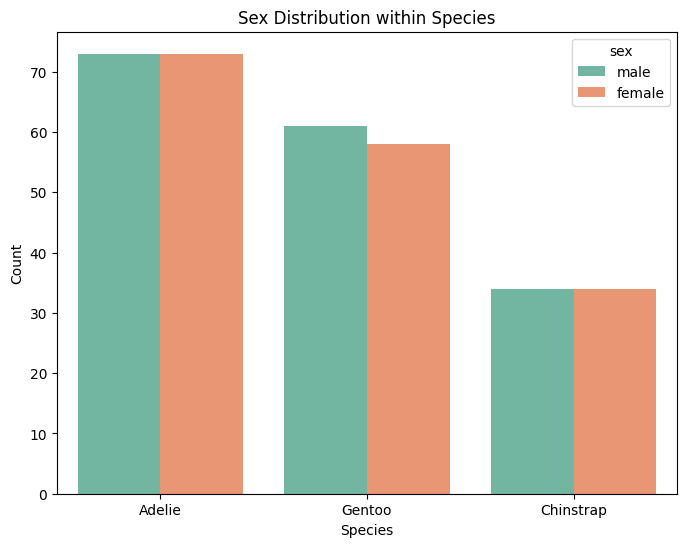

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.countplot(
    x="species",
    hue="sex",          # couleur par sexe
    data=df,
    palette="Set2"      # palette sympa
)

plt.title("Sex Distribution within Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

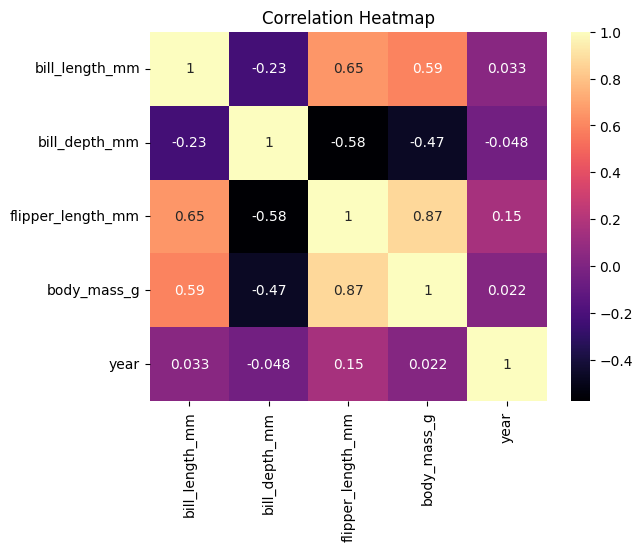

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='magma')
plt.title("Correlation Heatmap")
plt.show()

/tmp/ipython-input-690461921.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=f, data=df, palette='magma')


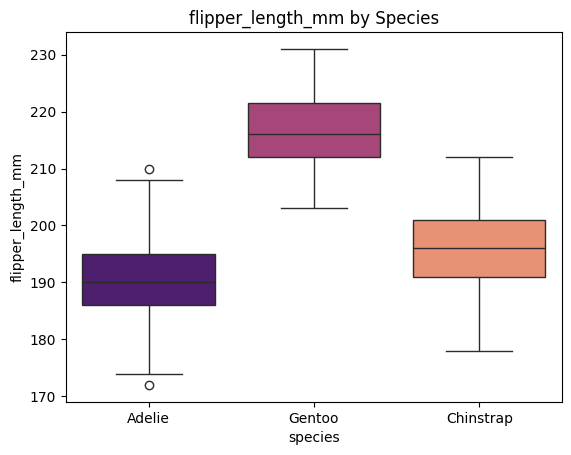

/tmp/ipython-input-690461921.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=f, data=df, palette='magma')


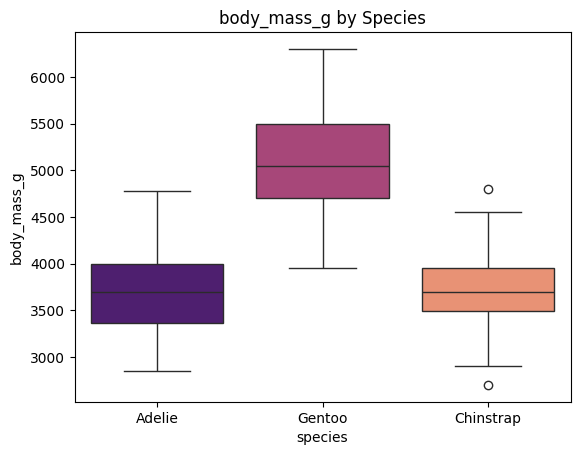

/tmp/ipython-input-690461921.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=f, data=df, palette='magma')


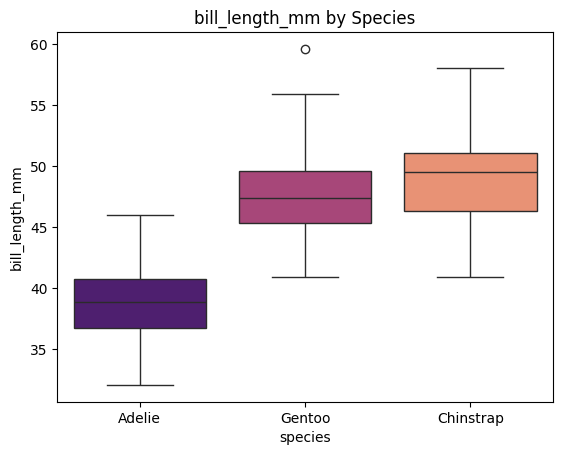

/tmp/ipython-input-690461921.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=f, data=df, palette='magma')


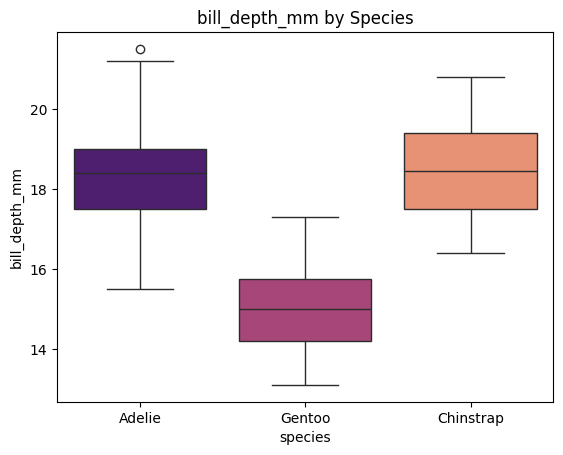

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ['flipper_length_mm', 'body_mass_g', 'bill_length_mm', 'bill_depth_mm']
for f in features:
    sns.boxplot(x='species', y=f, data=df, palette='magma')
    plt.title(f"{f} by Species")
    plt.show()


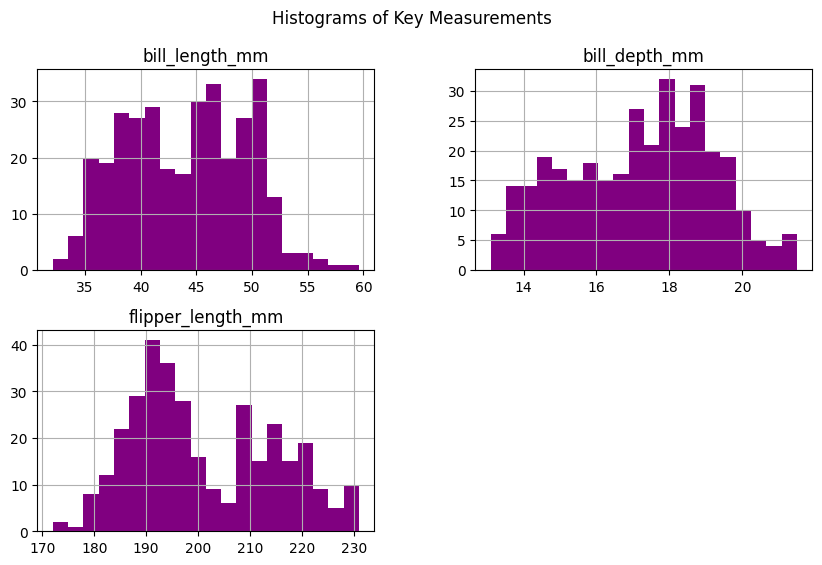

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

df[['bill_length_mm','bill_depth_mm','flipper_length_mm']].hist(bins=20, figsize=(10,6), color='purple')
plt.suptitle("Histograms of Key Measurements")
plt.show()

### Insightful Visualizations :

/tmp/ipython-input-3464191248.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='species', data=df, palette='magma', ax=axes[0])


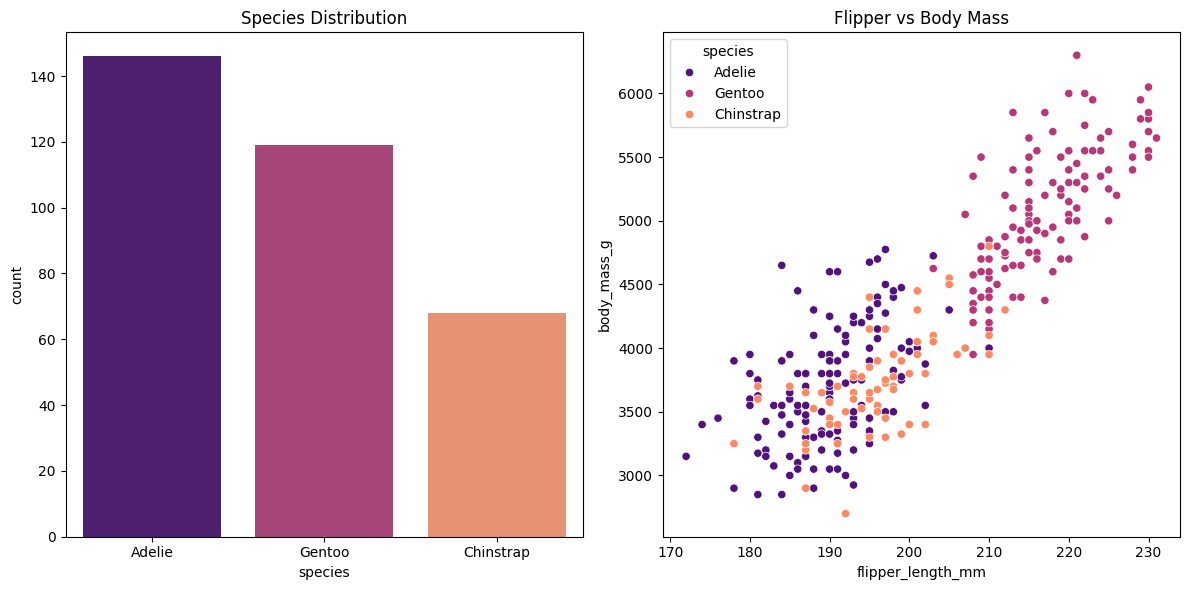

In [51]:
#subplot comparison
fig, axes = plt.subplots(1, 2, figsize=(12,6))

sns.countplot(x='species', data=df, palette='magma', ax=axes[0])
axes[0].set_title("Species Distribution")

sns.scatterplot(x='flipper_length_mm', y='body_mass_g',
                hue='species', data=df, palette='magma', ax=axes[1])
axes[1].set_title("Flipper vs Body Mass")

plt.tight_layout()
plt.show()

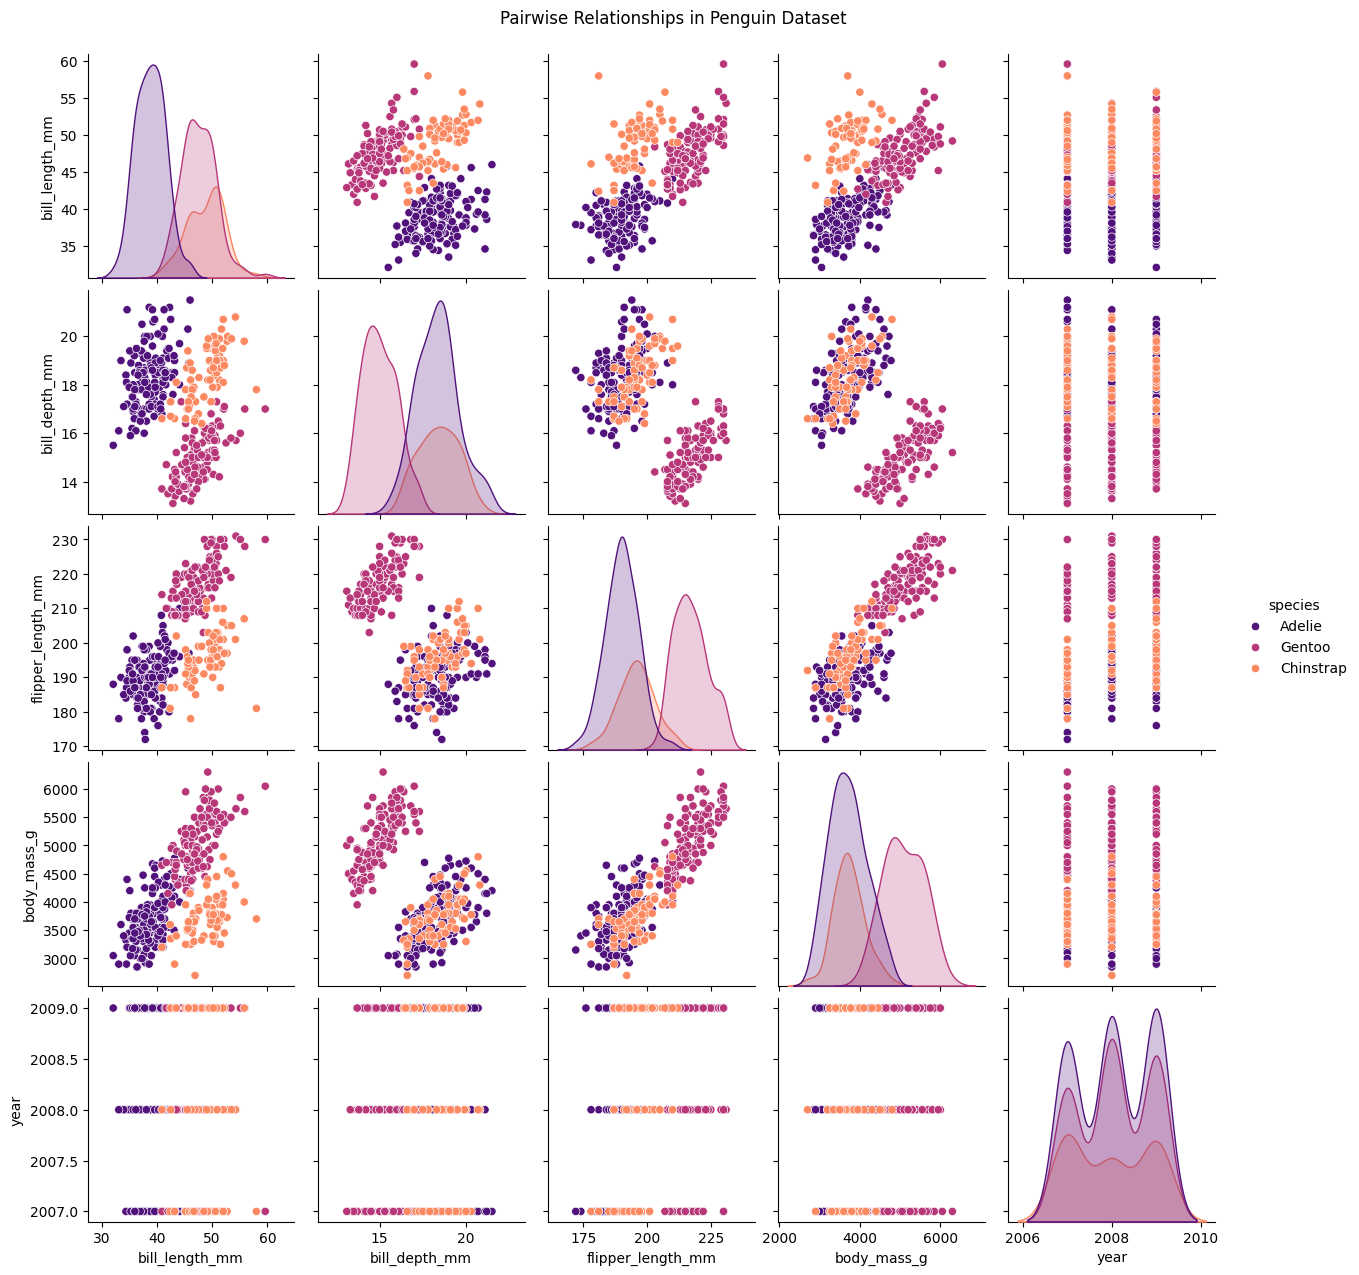

In [52]:
#pairplot
sns.pairplot(df, hue='species', palette='magma')
plt.suptitle("Pairwise Relationships in Penguin Dataset", y=1.02)
plt.show()